In [4]:
with open('/content/data_banknote_authentication.txt', 'r') as file:
  content = file.read()


In [5]:
import pandas as pd
import numpy as np
df = pd.read_csv('/content/data_banknote_authentication.txt', header=None)
display(df.head())

,0,1,2,3,4
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [6]:
print(df.shape)

(1372, 5)


In [7]:
print(df.isna().sum())

0    0
1    0
2    0
3    0
4    0
dtype: int64


In [8]:
df.describe()

,0,1,2,3,4
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


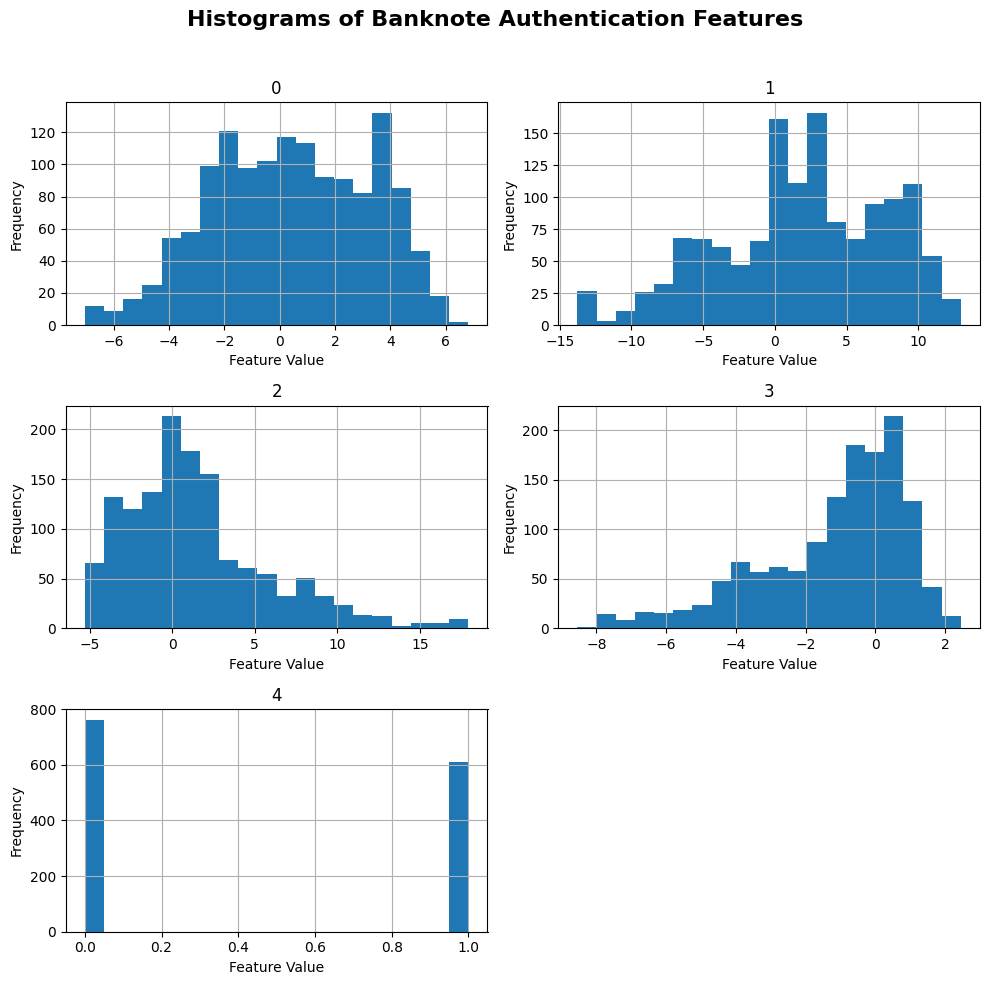

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create histograms
axes = df.hist(figsize=(10, 10),bins=20)

# Main title
plt.suptitle("Histograms of Banknote Authentication Features",
             fontsize=16,
             fontweight='bold')

# X and Y labels for each subplot
for ax in axes.flatten():
    ax.set_xlabel("Feature Value", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)

    # Add a legend
    #ax.legend([ax.get_title()], loc='upper right', fontsize=8)

# Adjust spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Save first
plt.savefig(
    "histogram.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

# Then display
plt.show()

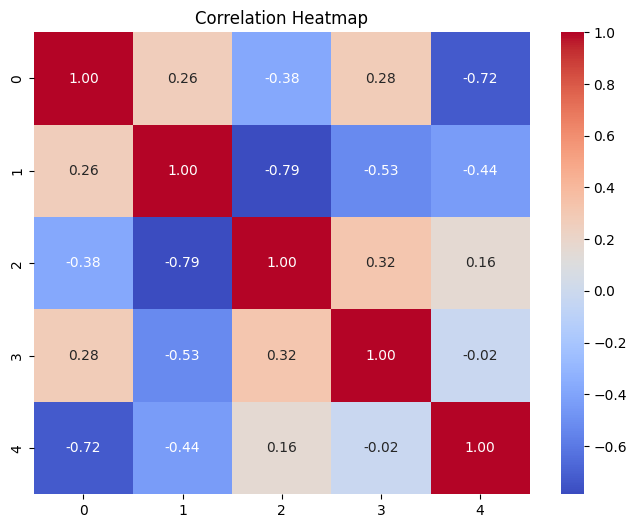

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.savefig("heatmap.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()


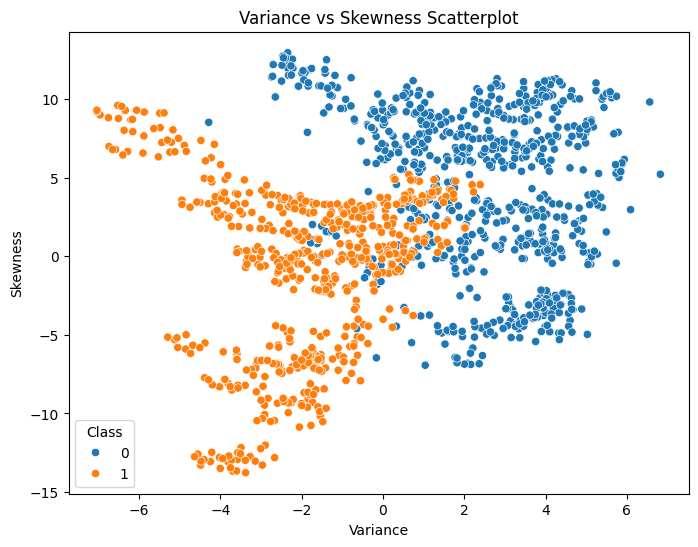

In [16]:
df.columns = ['Variance', 'Skewness', 'Curtosis', 'Entropy', 'Class']
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='Variance',
    y='Skewness',
    hue='Class'
)
plt.title("Variance vs Skewness Scatterplot")
plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.savefig("Scatterplot.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()


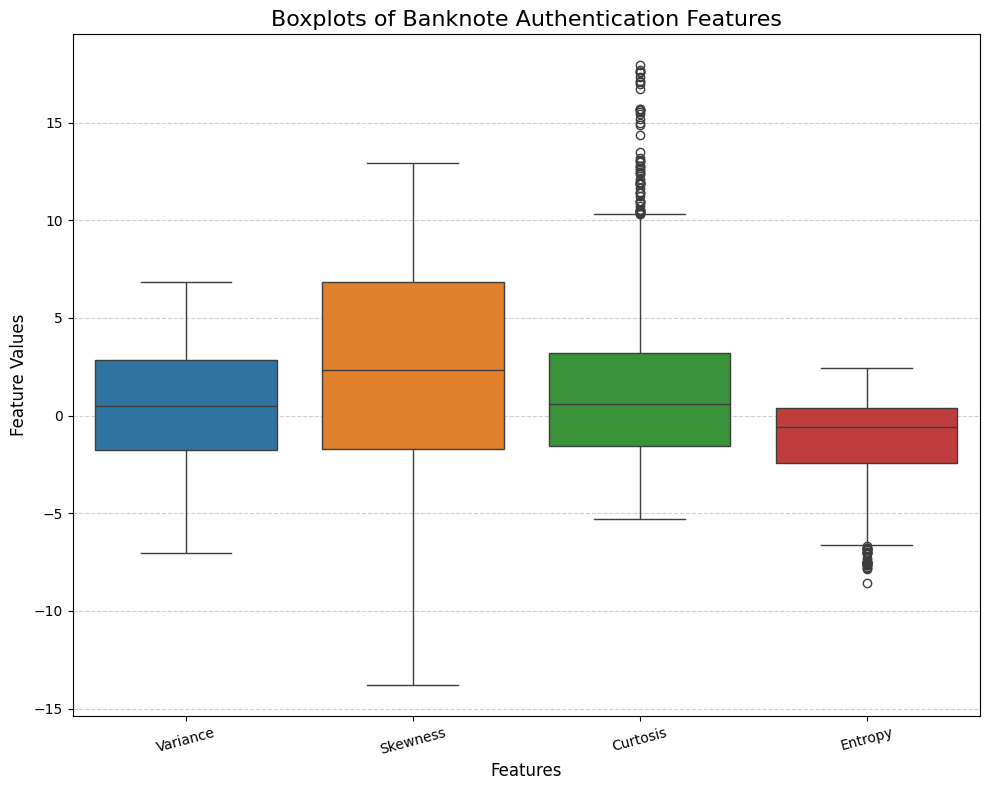

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.boxplot(data=df.iloc[:, :-1])

plt.title("Boxplots of Banknote Authentication Features", fontsize=16)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Feature Values", fontsize=12)

plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.savefig("Boxplot.eps",
            format="eps",
            dpi=600,
            bbox_inches="tight")

plt.show()

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = df[['Variance', 'Skewness', 'Curtosis', 'Entropy']]
y = df['Class']

X_normalized = scaler.fit_transform(X)



In [20]:
from sklearn.model_selection import train_test_split

x_training, x_testing, y_training, y_testing = train_test_split(X_normalized,y,test_size=0.20,random_state=42)

In [21]:
def step_function(x):
    if x >= 0:
        return 1
    else:
        return 0

In [22]:
n_features = x_training.shape[1]

weights = np.zeros(n_features)
bias = np.random.randn()

In [23]:
def predict(x, weights, bias):
    linear_output = np.dot(x, weights) + bias
    return step_function(linear_output)

In [24]:
learning_rate = 0.01
epochs = 50

n_features = x_training.shape[1]

weights = np.zeros(n_features)
bias = 0

training_errors = []
weight_history = []
bias_history = []

for epoch in range(epochs):

  misclassified=0

  for i in range(len(x_training)):

      x = x_training[i]
      target = y_training.iloc[i]

      linear_output = np.dot(x, weights) + bias
      prediction = 1 if linear_output >= 0 else 0

      error = target - prediction

      if error != 0:
          misclassified+=1

      weights = weights + learning_rate * error * x
      bias = bias+learning_rate*error

  training_errors.append(misclassified)
  weight_history.append(weights.copy())
  bias_history.append(bias)

  print("Epoch  Miscls  W1       W2       W3       W4       Bias")
  print("-"*65)

  print(f"{epoch+1:<6} "f"{misclassified:<7} "f"{weights[0]:<8.4f} "f"{weights[1]:<8.4f} "f"{weights[2]:<8.4f} "f"{weights[3]:<8.4f} "f"{bias:<8.4f}")



Epoch  Miscls  W1       W2       W3       W4       Bias
-----------------------------------------------------------------
1      47      -0.0725  -0.0649  -0.0645  0.0002   -0.0300 
Epoch  Miscls  W1       W2       W3       W4       Bias
-----------------------------------------------------------------
2      26      -0.0822  -0.0938  -0.0515  -0.0052  -0.0300 
Epoch  Miscls  W1       W2       W3       W4       Bias
-----------------------------------------------------------------
3      34      -0.0947  -0.0914  -0.0891  -0.0096  -0.0500 
Epoch  Miscls  W1       W2       W3       W4       Bias
-----------------------------------------------------------------
4      23      -0.1107  -0.0958  -0.1063  -0.0131  -0.0400 
Epoch  Miscls  W1       W2       W3       W4       Bias
-----------------------------------------------------------------
5      27      -0.1310  -0.1218  -0.0911  -0.0088  -0.0500 
Epoch  Miscls  W1       W2       W3       W4       Bias
----------------------------------

In [26]:
history = pd.DataFrame({
    "Epoch": range(1, epochs + 1),
    "Errors": training_errors,
    "W1": [w[0] for w in weight_history],
    "W2": [w[1] for w in weight_history],
    "W3": [w[2] for w in weight_history],
    "W4": [w[3] for w in weight_history],
    "Bias": bias_history
})

selected = history[history["Epoch"].isin([1,2,3,5,10,20,30,40,50])]

print(selected)

    Epoch  Errors        W1        W2        W3        W4  Bias
0       1      47 -0.072537 -0.064863 -0.064460  0.000199 -0.03
1       2      26 -0.082170 -0.093802 -0.051494 -0.005182 -0.03
2       3      34 -0.094676 -0.091400 -0.089055 -0.009565 -0.05
4       5      27 -0.130964 -0.121796 -0.091128 -0.008771 -0.05
9      10      26 -0.131687 -0.155810 -0.126006  0.011535 -0.06
19     20      17 -0.156418 -0.174663 -0.155186 -0.025960 -0.09
29     30      18 -0.175740 -0.187043 -0.178879 -0.013906 -0.10
39     40      21 -0.174245 -0.215330 -0.197946 -0.014856 -0.10
49     50      13 -0.196595 -0.219351 -0.210659 -0.018478 -0.10


In [27]:
predictions = []

for x in x_testing:
    linear_output = np.dot(x, weights) + bias
    prediction = 1 if linear_output >= 0 else 0
    predictions.append(prediction)

Accuracy : 0.9781818181818182
Precision: 0.984
Recall   : 0.968503937007874
F1 Score : 0.9761904761904762


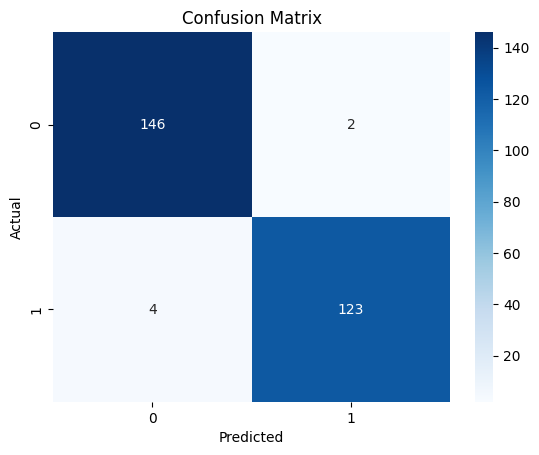

In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_testing, predictions)
precision = precision_score(y_testing, predictions)
recall = recall_score(y_testing, predictions)
f1 = f1_score(y_testing, predictions)
cm = confusion_matrix(y_testing, predictions)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['0', '1'],
    yticklabels=['0', '1']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

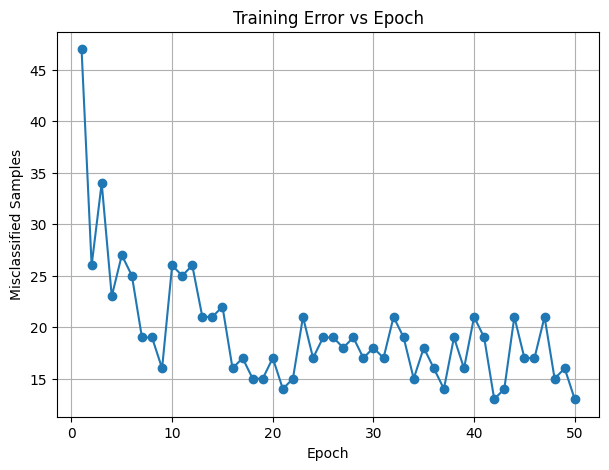

In [65]:
plt.figure(figsize=(7,5))
plt.plot(range(1, epochs+1), training_errors, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Training Error vs Epoch")
plt.grid(True)
plt.savefig("training error vs epoch.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

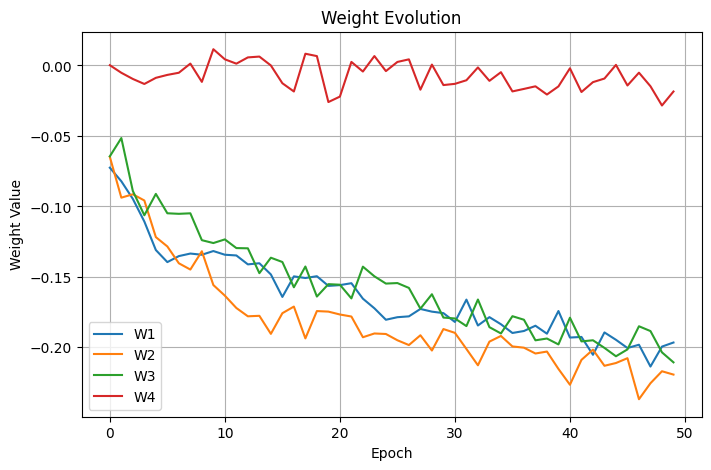

In [72]:
weight_history = np.array(weight_history)

plt.figure(figsize=(8,5))

for i in range(weight_history.shape[1]):
    plt.plot(weight_history[:, i], label=f"W{i+1}")

plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.title("Weight Evolution")
plt.legend()
plt.grid(True)
plt.savefig("weight_evolution.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

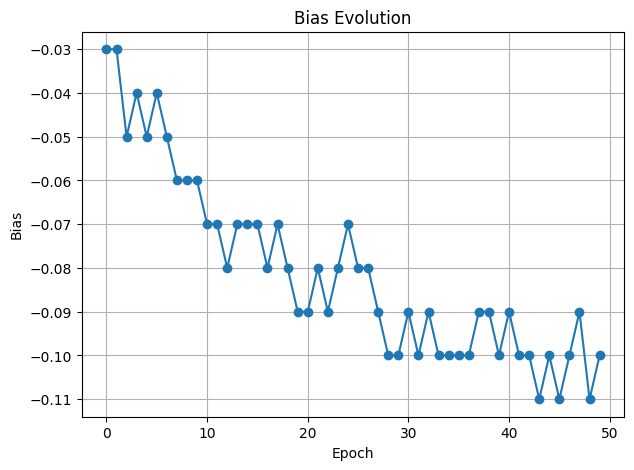

In [73]:
plt.figure(figsize=(7,5))
plt.plot(bias_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Bias")
plt.title("Bias Evolution")
plt.grid(True)
plt.savefig("bias_evolution.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

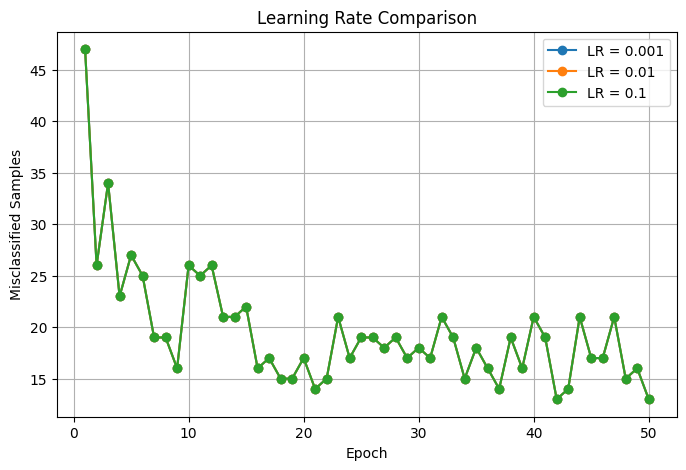

In [75]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(8,5))

for lr in learning_rates:

    weights = np.zeros(x_training.shape[1])
    bias = 0

    errors = []

    for epoch in range(epochs):

        misclassified = 0

        for i in range(len(x_training)):

            x = x_training[i]
            target = y_training.iloc[i]

            output = np.dot(x, weights) + bias
            prediction = 1 if output >= 0 else 0

            error = target - prediction

            if error != 0:
                misclassified += 1

            weights += lr * error * x
            bias += lr * error

        errors.append(misclassified)


    # Plot one line for this learning rate
    plt.plot(range(1, epochs + 1), errors, marker='o', label=f"LR = {lr}")

# These should be OUTSIDE the loop
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.title("Learning Rate Comparison")
plt.legend()
plt.grid(True)
plt.savefig("learning_rate_comparison.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [69]:
print("\nTRAINING SUMMARY")
print("-" * 45)

print(f"{'Dataset Size':<20}: {len(df)}")
print(f"{'Train/Test Split':<20}: 80% / 20%")
print(f"{'Learning Rate':<20}: {learning_rate}")
print(f"{'Epochs':<20}: {epochs}")
print(f"{'Final Weights':<20}: {weights}")
print(f"{'Final Bias':<20}: {bias:.4f}")
print(f"{'Accuracy':<20}: {accuracy:.4f}")
print(f"{'Precision':<20}: {precision:.4f}")
print(f"{'Recall':<20}: {recall:.4f}")
print(f"{'F1-score':<20}: {f1:.4f}")


TRAINING SUMMARY
---------------------------------------------
Dataset Size        : 1372
Train/Test Split    : 80% / 20%
Learning Rate       : 0.01
Epochs              : 50
Final Weights       : [-1.96594684 -2.19350721 -2.10659444 -0.18477944]
Final Bias          : -1.0000
Accuracy            : 0.9782
Precision           : 0.9840
Recall              : 0.9685
F1-score            : 0.9762


In [70]:
print("\nEPOCH-WISE LEARNING")
print("-" * 60)
print(f"{'Epoch':<8}{'Errors':<10}{'Weight 1':<12}{'Weight 2':<12}{'Bias':<12}")

for i in range(epochs):
    print(f"{i+1:<8}"
          f"{training_errors[i]:<10}"
          f"{weight_history[i][0]:<12.4f}"
          f"{weight_history[i][1]:<12.4f}"
          f"{bias_history[i]:<12.4f}")


EPOCH-WISE LEARNING
------------------------------------------------------------
Epoch   Errors    Weight 1    Weight 2    Bias        
1       47        -0.0725     -0.0649     -0.0300     
2       26        -0.0822     -0.0938     -0.0300     
3       34        -0.0947     -0.0914     -0.0500     
4       23        -0.1107     -0.0958     -0.0400     
5       27        -0.1310     -0.1218     -0.0500     
6       25        -0.1395     -0.1284     -0.0400     
7       19        -0.1353     -0.1404     -0.0500     
8       19        -0.1335     -0.1448     -0.0600     
9       16        -0.1343     -0.1318     -0.0600     
10      26        -0.1317     -0.1558     -0.0600     
11      25        -0.1343     -0.1633     -0.0700     
12      26        -0.1348     -0.1721     -0.0700     
13      21        -0.1411     -0.1780     -0.0800     
14      21        -0.1403     -0.1776     -0.0700     
15      22        -0.1483     -0.1904     -0.0700     
16      16        -0.1642     -0.1758 

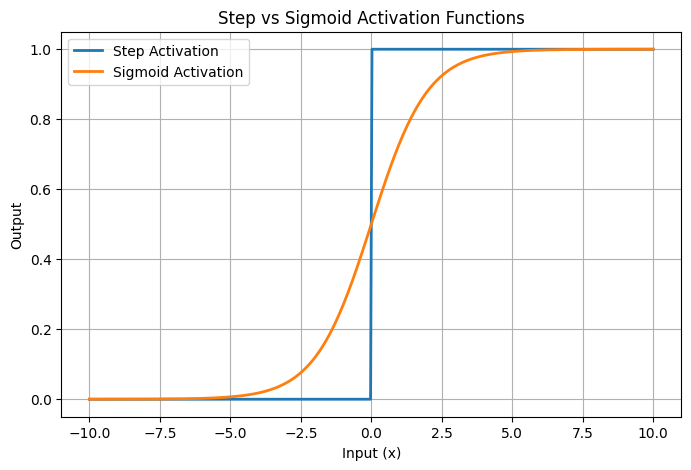

In [71]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 400)

# Step Activation
step = np.where(x >= 0, 1, 0)

# Sigmoid Activation
sigmoid = 1 / (1 + np.exp(-x))

plt.figure(figsize=(8,5))
plt.plot(x, step, label="Step Activation", linewidth=2)
plt.plot(x, sigmoid, label="Sigmoid Activation", linewidth=2)

plt.xlabel("Input (x)")
plt.ylabel("Output")
plt.title("Step vs Sigmoid Activation Functions")
plt.grid(True)
plt.legend()
plt.savefig("activation_functions.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()